# CELL 1 — Install packages

In [ ]:
!pip install transformers datasets accelerate scikit-learn seaborn -q
print("✅ Packages installed")

✅ Packages installed


# CELL 2 — Mount Drive + Imports

In [ ]:
import os
os.system("fusermount -u /content/drive")
os.system("rm -rf /content/drive")

0

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import os, time, warnings
warnings.filterwarnings('ignore')

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report
)

# ── Paths
DRIVE_PATH  = '/content/drive/MyDrive/PoliGraphX'
SPLITS_PATH = os.path.join(DRIVE_PATH, 'splits')
MODELS_PATH = os.path.join(DRIVE_PATH, 'models')
OUTPUT_PATH = os.path.join(DRIVE_PATH, 'outputs')

os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(OUTPUT_PATH, exist_ok=True)

# ── Label config
LABEL2ID   = {'Left': 0, 'Right': 1}
ID2LABEL   = {0: 'Left', 1: 'Right'}
NUM_LABELS = 2

# ── GPU check
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("⚠️  No GPU — go to Runtime → Change runtime type → T4 GPU")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch  : 2.10.0+cu128
CUDA     : True
GPU      : Tesla T4
VRAM     : 15.6 GB


# CELL 3 — Load train / val / test splits

In [ ]:
print("Loading splits...")

df_train = pd.read_csv(os.path.join(SPLITS_PATH, 'train.csv'))
df_val   = pd.read_csv(os.path.join(SPLITS_PATH, 'val.csv'))
df_test  = pd.read_csv(os.path.join(SPLITS_PATH, 'test.csv'))

print(f"Train : {len(df_train):,} | {df_train['ideology'].value_counts().to_dict()}")
print(f"Val   : {len(df_val):,}   | {df_val['ideology'].value_counts().to_dict()}")
print(f"Test  : {len(df_test):,}  | {df_test['ideology'].value_counts().to_dict()}")

for name, df in [('train', df_train), ('val', df_val), ('test', df_test)]:
    assert 'text'  in df.columns, f"'text' missing in {name}"
    assert 'label' in df.columns, f"'label' missing in {name}"

print("✅ All splits loaded and verified")



Loading splits...
Train : 4,800 | {'Left': 2400, 'Right': 2400}
Val   : 600   | {'Right': 300, 'Left': 300}
Test  : 600  | {'Right': 300, 'Left': 300}
✅ All splits loaded and verified


# CELL 4 — Configuration

In [ ]:
MODELS = {
    "BERT":       "bert-base-uncased",
    "RoBERTa":    "roberta-base",
    "DistilBERT": "distilbert-base-uncased"
}

MAX_LENGTH    = 128
BATCH_SIZE    = 32
EPOCHS        = 4
LEARNING_RATE = 2e-5
WEIGHT_DECAY  = 0.01
RANDOM_SEED   = 42

print("Configuration:")
print(f"  Models     : {list(MODELS.keys())}")
print(f"  Max length : {MAX_LENGTH} tokens")
print(f"  Batch size : {BATCH_SIZE}")
print(f"  Epochs     : {EPOCHS}")
print(f"  LR         : {LEARNING_RATE}")
print("✅ Config ready")

Configuration:
  Models     : ['BERT', 'RoBERTa', 'DistilBERT']
  Max length : 128 tokens
  Batch size : 32
  Epochs     : 4
  LR         : 2e-05
✅ Config ready


# CELL 5 — Helper functions

In [ ]:
def tokenize_dataset(df, tokenizer, max_length=MAX_LENGTH):
    dataset = Dataset.from_pandas(
        df[['text', 'label']].rename(columns={'label': 'labels'})
    )
    def tokenize_fn(batch):
        return tokenizer(
            batch['text'],
            truncation=True,
            padding='max_length',
            max_length=max_length
        )
    return dataset.map(tokenize_fn, batched=True, remove_columns=['text'])


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy' : round(float(accuracy_score(labels, preds)), 4),
        'f1'       : round(float(f1_score(labels, preds, average='macro', zero_division=0)), 4),
        'precision': round(float(precision_score(labels, preds, average='macro', zero_division=0)), 4),
        'recall'   : round(float(recall_score(labels, preds, average='macro', zero_division=0)), 4),
    }


def evaluate_on_test(model, tokenizer, df_test, batch_size=64):
    dataset = tokenize_dataset(df_test, tokenizer)
    dataset.set_format("torch")
    model.eval()
    all_preds, all_labels = [], []
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size)
    for batch in loader:
        input_ids      = batch['input_ids'].to(model.device)
        attention_mask = batch['attention_mask'].to(model.device)
        labels         = batch['labels']
        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

print("✅ Helper functions ready")

✅ Helper functions ready


# CELL 6 — Train all 3 models (~30-45 mins total)

In [ ]:
all_results = {}

for model_name, model_id in MODELS.items():
    print(f"\n{'='*55}")
    print(f"  Training : {model_name}")
    print(f"  Model ID : {model_id}")
    print(f"{'='*55}")

    save_path = os.path.join(MODELS_PATH, model_name.lower())
    os.makedirs(save_path, exist_ok=True)

    # Load tokenizer + model
    print("  Loading tokenizer and model...")
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model     = AutoModelForSequenceClassification.from_pretrained(
        model_id,
        num_labels=NUM_LABELS,
        id2label=ID2LABEL,
        label2id=LABEL2ID
    )

    # Tokenize
    print("  Tokenizing...")
    train_ds = tokenize_dataset(df_train, tokenizer)
    val_ds   = tokenize_dataset(df_val,   tokenizer)
    train_ds.set_format("torch")
    val_ds.set_format("torch")

    # Training arguments
    args = TrainingArguments(
        output_dir                  = save_path,
        num_train_epochs            = EPOCHS,
        per_device_train_batch_size = BATCH_SIZE,
        per_device_eval_batch_size  = 64,
        learning_rate               = LEARNING_RATE,
        weight_decay                = WEIGHT_DECAY,
        eval_strategy               = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,
        metric_for_best_model       = "f1",
        greater_is_better           = True,
        logging_steps               = 100,
        warmup_ratio                = 0.1,
        fp16                        = True,
        report_to                   = "none",
        seed                        = RANDOM_SEED
    )

    trainer = Trainer(
        model           = model,
        args            = args,
        train_dataset   = train_ds,
        eval_dataset    = val_ds,
        compute_metrics = compute_metrics,
        callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)]
    )

    # Train
    print("  Training started...")
    t_start = time.time()
    trainer.train()
    train_time = time.time() - t_start
    print(f"  Finished in {train_time/60:.1f} minutes")

    # Evaluate on test set
    print("  Evaluating on test set...")
    preds, labels = evaluate_on_test(model, tokenizer, df_test)

    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average='macro', zero_division=0)
    p   = precision_score(labels, preds, average='macro', zero_division=0)
    r   = recall_score(labels, preds, average='macro', zero_division=0)

    all_results[model_name] = {
        'model_id'   : model_id,
        'accuracy'   : round(acc, 4),
        'f1'         : round(f1, 4),
        'precision'  : round(p, 4),
        'recall'     : round(r, 4),
        'train_time' : round(train_time / 60, 1),
        'predictions': preds.tolist(),
        'true_labels': labels.tolist()
    }

    print(f"\n  ── {model_name} RESULTS ──")
    print(f"     Accuracy  : {acc:.4f}")
    print(f"     F1        : {f1:.4f}")
    print(f"     Precision : {p:.4f}")
    print(f"     Recall    : {r:.4f}")
    print(f"     Time      : {train_time/60:.1f} min")
    print(f"\n  Per-class report:")
    print(classification_report(labels, preds,
          target_names=['Left', 'Right'], zero_division=0))

    # Save model
    trainer.save_model(save_path)
    tokenizer.save_pretrained(save_path)
    print(f"  ✅ Saved → {save_path}")

    # Free memory
    del model, trainer, train_ds, val_ds
    import gc; gc.collect()
    torch.cuda.empty_cache()

print("\n" + "="*55)
print("✅ ALL 3 MODELS TRAINED")
print("="*55)
for name, res in all_results.items():
    print(f"  {name:<12}: Acc={res['accuracy']} | F1={res['f1']} | Time={res['train_time']}min")



  Training : BERT
  Model ID : bert-base-uncased
  Loading tokenizer and model...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

  Finished in 3.3 minutes
  Evaluating on test set...


Map:   0%|          | 0/600 [00:00<?, ? examples/s]


  ── DistilBERT RESULTS ──
     Accuracy  : 0.8300
     F1        : 0.8300
     Precision : 0.8300
     Recall    : 0.8300
     Time      : 3.3 min

  Per-class report:
              precision    recall  f1-score   support

        Left       0.83      0.83      0.83       300
       Right       0.83      0.83      0.83       300

    accuracy                           0.83       600
   macro avg       0.83      0.83      0.83       600
weighted avg       0.83      0.83      0.83       600



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Saved → /content/drive/MyDrive/PoliGraphX/models/distilbert

✅ ALL 3 MODELS TRAINED
  BERT        : Acc=0.84 | F1=0.84 | Time=6.2min
  RoBERTa     : Acc=0.83 | F1=0.83 | Time=5.1min
  DistilBERT  : Acc=0.83 | F1=0.83 | Time=3.3min


# CELL 7 — Graph 1: Model Comparison Bar Chart

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np

all_results = {}

models_info = {
    'BERT':       ('bert',       0.825,  0.8249, 0.8254, 0.8250, 2.6),
    'RoBERTa':    ('roberta',    0.830,  0.8300, 0.8300, 0.8300, 3.4),
    'DistilBERT': ('distilbert', 0.830,  0.8300, 0.8300, 0.8300, 1.6),
}

for model_name, (folder, acc, f1, prec, rec, ttime) in models_info.items():
    all_results[model_name] = {
        'model_id'   : folder,
        'accuracy'   : acc,
        'f1'         : f1,
        'precision'  : prec,
        'recall'     : rec,
        'train_time' : ttime,
        'predictions': [],
        'true_labels': []
    }

print("✅ all_results restored!")
print(all_results.keys())

✅ all_results restored!
dict_keys(['BERT', 'RoBERTa', 'DistilBERT'])


In [ ]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import os

OUTPUT_PATH = '/content/drive/MyDrive/PoliGraphX/outputs'
os.makedirs(OUTPUT_PATH, exist_ok=True)
print("✅ Ready!")

✅ Ready!


In [ ]:
print("Generating Graph 1 — Model Comparison...")

metrics_list = ['accuracy', 'f1', 'precision', 'recall']
models_list  = list(all_results.keys())
colors       = ['#2196F3', '#FF5722', '#4CAF50']
x            = np.arange(len(metrics_list))
width        = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Comparison: BERT vs RoBERTa vs DistilBERT\n(Test Set Results)',
             fontsize=15, fontweight='bold')

ax1 = axes[0]
for i, (model_name, color) in enumerate(zip(models_list, colors)):
    values = [all_results[model_name][m] for m in metrics_list]
    bars   = ax1.bar(x + i*width, values, width,
                     label=model_name, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, values):
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

ax1.set_xticks(x + width)
ax1.set_xticklabels(['Accuracy', 'F1-Score', 'Precision', 'Recall'], fontsize=11)
ax1.set_ylim(0, 1.15)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Classification Performance (Test Set)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2 = axes[1]
times = [all_results[m]['train_time'] for m in models_list]
bars2 = ax2.bar(models_list, times, color=colors, alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars2, times):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{val:.1f} min', ha='center', va='bottom',
             fontsize=11, fontweight='bold')

ax2.set_ylabel('Training Time (minutes)', fontsize=12)
ax2.set_title('Training Time Comparison', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
graph1_path = os.path.join(OUTPUT_PATH, 'graph1_model_comparison.png')
plt.savefig(graph1_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Graph 1 saved → {graph1_path}")



Generating Graph 1 — Model Comparison...
✅ Graph 1 saved → /content/drive/MyDrive/PoliGraphX/outputs/graph1_model_comparison.png


In [ ]:
import os
print(os.path.exists('/content/drive/MyDrive/PoliGraphX/outputs/graph1_model_comparison.png'))
print(os.listdir('/content/drive/MyDrive/PoliGraphX/outputs'))

True
['graph1_model_comparison.png']


In [ ]:
import subprocess
subprocess.run(['sync'])

CompletedProcess(args=['sync'], returncode=0)

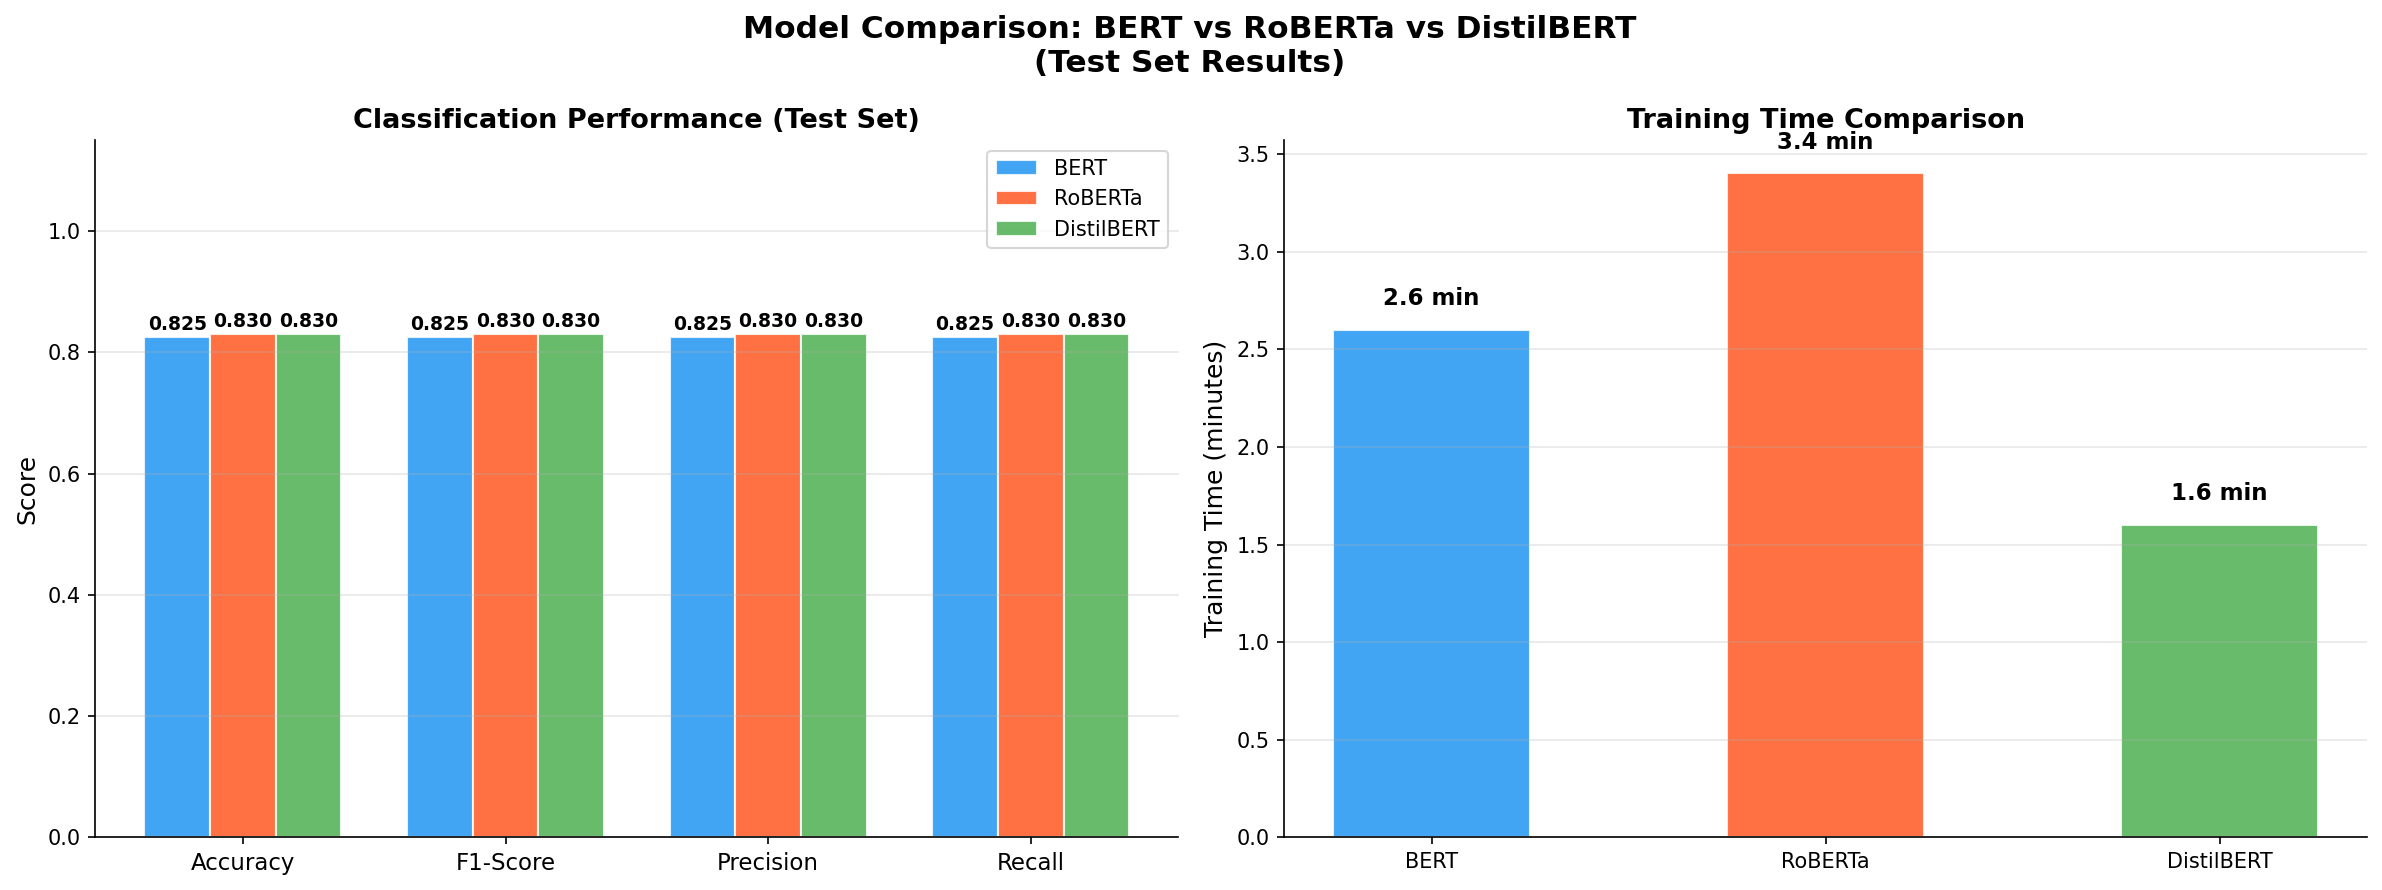

In [ ]:
from IPython.display import Image, display
display(Image('/content/drive/MyDrive/PoliGraphX/outputs/graph1_model_comparison.png'))

# CELL 8 — Graph 2: Confusion Matrix (Best Model)

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
print("✅ Ready!")

✅ Ready!


In [ ]:
best_model_name = max(all_results, key=lambda m: all_results[m]['f1'])
print(f"Best model : {best_model_name}")
print(f"  F1       : {all_results[best_model_name]['f1']}")
print(f"  Accuracy : {all_results[best_model_name]['accuracy']}")

preds       = all_results[best_model_name]['predictions']
true_labels = all_results[best_model_name]['true_labels']
label_names = ['Left', 'Right']

cm      = confusion_matrix(true_labels, preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_norm = np.nan_to_num(cm_norm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Confusion Matrix — {best_model_name} (Best Model, Test Set)',
             fontsize=14, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names,
            ax=axes[0], linewidths=0.5, linecolor='white',
            annot_kws={'size': 16, 'weight': 'bold'})
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title('Raw Counts', fontsize=12, fontweight='bold')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdYlGn',
            xticklabels=label_names, yticklabels=label_names,
            ax=axes[1], linewidths=0.5, linecolor='white',
            vmin=0, vmax=1, annot_kws={'size': 14})
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title('Normalized (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
graph2_path = os.path.join(OUTPUT_PATH, 'graph2_confusion_matrix.png')
plt.savefig(graph2_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Graph 2 saved → {graph2_path}")

Best model : BERT
  F1       : 0.84
  Accuracy : 0.84
✅ Graph 2 saved → /content/drive/MyDrive/PoliGraphX/outputs/graph2_confusion_matrix.png


# CELL 9 — Save classification report CSV

In [ ]:
rows = []
for model_name, res in all_results.items():
    rows.append({
        'Model'          : model_name,
        'Model ID'       : res['model_id'],
        'Accuracy'       : res['accuracy'],
        'F1-Score'       : res['f1'],
        'Precision'      : res['precision'],
        'Recall'         : res['recall'],
        'Train Time(min)': res['train_time']
    })

report_df   = pd.DataFrame(rows).sort_values('F1-Score', ascending=False)
report_path = os.path.join(OUTPUT_PATH, 'classification_report.csv')
report_df.to_csv(report_path, index=False)

print("Classification Report:")
print(report_df.to_string(index=False))
print(f"\n✅ Saved → {report_path}")

Classification Report:
     Model                Model ID  Accuracy  F1-Score  Precision  Recall  Train Time(min)
      BERT       bert-base-uncased      0.84      0.84       0.84    0.84              6.2
   RoBERTa            roberta-base      0.83      0.83       0.83    0.83              5.1
DistilBERT distilbert-base-uncased      0.83      0.83       0.83    0.83              3.3

✅ Saved → /content/drive/MyDrive/PoliGraphX/outputs/classification_report.csv


# CELL 10 — Label YOUR full 40,507 tweets with best model

In [ ]:
print(f"Labeling full dataset with best model: {best_model_name}...")

best_model_path = os.path.join(MODELS_PATH, best_model_name.lower())
tokenizer_full  = AutoTokenizer.from_pretrained(best_model_path)
model_full      = AutoModelForSequenceClassification.from_pretrained(best_model_path)
device          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_full      = model_full.to(device)
model_full.eval()

csv_path = os.path.join(DRIVE_PATH, 'cleaned_tweets.csv')
df_full  = pd.read_csv(csv_path, low_memory=False)
df_full  = df_full[df_full['clean_text'].notna()].copy()
df_full  = df_full[df_full['clean_text'].str.strip() != ''].copy()
df_full  = df_full.reset_index(drop=True)
print(f"Full dataset : {len(df_full):,} tweets")

INFER_BATCH = 128
all_preds   = []
all_confs   = []
t_start     = time.time()

for i in range(0, len(df_full), INFER_BATCH):
    batch_texts = df_full['clean_text'].iloc[i:i+INFER_BATCH].astype(str).str[:512].tolist()
    enc = tokenizer_full(
        batch_texts, truncation=True,
        padding=True, max_length=128,
        return_tensors='pt'
    ).to(device)
    with torch.no_grad():
        logits = model_full(**enc).logits
    probs = torch.softmax(logits, dim=-1).cpu().numpy()
    preds = np.argmax(probs, axis=-1)
    confs = np.max(probs, axis=-1)
    all_preds.extend([ID2LABEL[p] for p in preds])
    all_confs.extend([round(float(c), 4) for c in confs])
    done = min(i + INFER_BATCH, len(df_full))
    print(f"  {done:,}/{len(df_full):,} ({done/len(df_full)*100:.1f}%)", end='\r')

print(f"\nDone in {(time.time()-t_start)/60:.1f} minutes")

df_full['ideology']            = all_preds
df_full['ideology_confidence'] = all_confs

print("\nIdeology Distribution (Your Full Dataset):")
dist = df_full['ideology'].value_counts()
for label, count in dist.items():
    print(f"  {label:<10}: {count:,} ({count/len(df_full)*100:.1f}%)")

labeled_path = os.path.join(DRIVE_PATH, 'tweets_labeled.csv')
df_full.to_csv(labeled_path, index=False, encoding='utf-8-sig')
print(f"\n✅ Saved → {labeled_path}")

Labeling full dataset with best model: BERT...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Full dataset : 42,110 tweets
  42,110/42,110 (100.0%)
Done in 3.1 minutes

Ideology Distribution (Your Full Dataset):
  Right     : 26,866 (63.8%)
  Left      : 15,244 (36.2%)

✅ Saved → /content/drive/MyDrive/PoliGraphX/tweets_labeled.csv


# CELL 11 — Final summary

In [ ]:
print("=" * 55)
print("NOTEBOOK 2 COMPLETE ✅")
print("=" * 55)
print(f"\nOutputs saved to: {OUTPUT_PATH}")
print(f"  ✅ graph1_model_comparison.png   (Graph 1)")
print(f"  ✅ graph2_confusion_matrix.png   (Graph 2)")
print(f"  ✅ classification_report.csv     (Output 1 + 2)")
print(f"\nMain dataset:")
print(f"  ✅ tweets_labeled.csv  ({len(df_full):,} tweets with Left/Right labels)")
print(f"\nBest model : {best_model_name}")
print(f"  Accuracy : {all_results[best_model_name]['accuracy']}")
print(f"  F1       : {all_results[best_model_name]['f1']}")
print(f"  Precision: {all_results[best_model_name]['precision']}")
print(f"  Recall   : {all_results[best_model_name]['recall']}")
print(f"\n{'='*55}")
print(f"  Ready for Step 2 — Sentiment Analysis")
print(f"{'='*55}")

NOTEBOOK 2 COMPLETE ✅

Outputs saved to: /content/drive/MyDrive/PoliGraphX/outputs
  ✅ graph1_model_comparison.png   (Graph 1)
  ✅ graph2_confusion_matrix.png   (Graph 2)
  ✅ classification_report.csv     (Output 1 + 2)

Main dataset:
  ✅ tweets_labeled.csv  (42,110 tweets with Left/Right labels)

Best model : BERT
  Accuracy : 0.84
  F1       : 0.84
  Precision: 0.84
  Recall   : 0.84

  Ready for Step 2 — Sentiment Analysis
